In [4]:
import pandas as pd
import numpy as np
import scipy as sp
import seaborn as sns
import statsmodels as sm
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv('data/incidenti_comuni.csv')

In [6]:
df['Popolazione'] = df['Popolazione'].astype('Int64')
df['Area(kmq)'] = round(df['Area(kmq)'], 2)

In [40]:
df["Classe ampiezza demografica"] = [
    "Piccolo (<5k)" if i < 5000
    else "Medio (5k-250k)" if i < 250000
    else "Grande (>250k)"
    for i in df["Popolazione"]
]

In [41]:
df

,Nome Comune,Codice Comune,Area(kmq),Popolazione,Incidenti,Feriti,Morti,Anno,Classe ampiezza demografica,Incidentix1000abitanti,Incidentixkm²,ab/km²,morti+feriti/incidenti
0,Agliè,1001,13.15,2557,5,10,0,2001,Piccolo (<5k),1.955,0.38,194.45,2.00
1,Agliè,1001,13.15,2538,5,10,0,2002,Piccolo (<5k),1.97,0.38,193.0,2.00
2,Agliè,1001,13.15,2588,4,7,0,2003,Piccolo (<5k),1.546,0.30,196.81,1.75
3,Agliè,1001,13.15,2679,9,13,0,2004,Piccolo (<5k),3.359,0.68,203.73,1.44
4,Agliè,1001,13.15,2674,2,2,0,2005,Piccolo (<5k),0.748,0.15,203.35,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
197234,Villaspeciosa,111107,27.19,2536,5,7,0,2021,Piccolo (<5k),1.972,0.18,93.27,1.40
197235,Villaspeciosa,111107,27.19,2575,1,1,0,2022,Piccolo (<5k),0.388,0.04,94.7,1.00
197236,Villaspeciosa,111107,27.19,2616,4,5,0,2023,Piccolo (<5k),1.529,0.15,96.21,1.25
197237,Villaspeciosa,111107,27.19,2628,3,5,0,2024,Piccolo (<5k),1.142,0.11,96.65,1.67


In [12]:
#Tasso x 1000 abitanti mi dà la relazione con la popolazione, quanto è diffuso
df['Incidentix1000abitanti'] = round(df['Incidenti']/(df['Popolazione']/1000), 3)
#Tasso per km2 mi dà quanto è concentrato.
df['Incidentixkm²'] = round(df['Incidenti']/(df['Area(kmq)']), 2)
# abitanti per km2 serve per analisi bivariata
df['ab/km²'] = round(df['Popolazione']/(df['Area(kmq)']), 2)
#Tasso di mortiferiti per incidenti mi dà quanto è grave.
df['morti+feriti/incidenti'] = round((df['Feriti']+df['Morti'])/(df['Incidenti']), 2)

In [9]:
df.describe()

,Codice Comune,Area(kmq),Popolazione,Incidenti,Feriti,Morti,Anno,Incidentix1000abitanti,Incidentixkm²,ab/km²,morti+feriti/incidenti
count,197239.000000,197239.000000,197239.0,197239.000000,197239.000000,197239.000000,197239.000000,197239.0,197239.000000,197239.0,156158.000000
mean,44511.180187,37.829395,7477.448552,25.077789,35.153879,0.531558,2012.714174,2.00197,0.715540,298.768063,1.544895
std,32065.940022,50.557440,41202.181665,256.766267,336.710184,2.766940,7.058551,2.342511,2.052693,638.050557,0.584755
min,1001.000000,0.120000,28.0,0.000000,0.000000,0.000000,2001.000000,0.0,0.000000,0.73,1.000000
25%,16144.000000,11.360000,1047.0,1.000000,1.000000,0.000000,2007.000000,0.473,0.030000,45.86,1.170000
50%,38010.000000,22.220000,2470.0,4.000000,5.000000,0.000000,2013.000000,1.518,0.160000,107.59,1.440000
75%,71048.000000,43.910000,6179.0,12.000000,18.000000,0.000000,2019.000000,2.796,0.570000,276.085,1.750000
max,111107.000000,1288.190000,2820219.0,23135.000000,30254.000000,363.000000,2024.000000,175.309,99.220000,13112.42,26.000000


## Popolazione

<Axes: xlabel='Popolazione'>

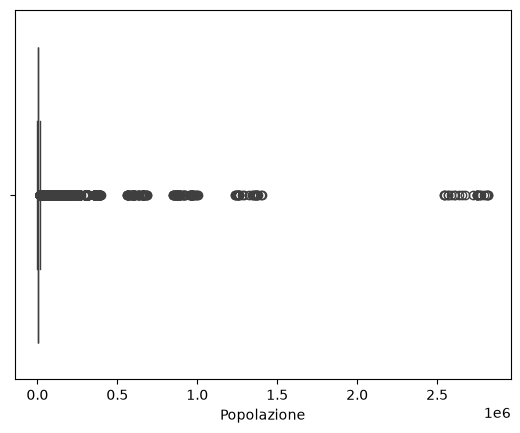

In [ ]:
sns.boxplot(x='Popolazione', data=df)
# sulla destra abbiamo Roma che appare per tutti gli anni.
# intorno a 1.4 milioni c'è Milano

<Axes: xlabel='Popolazione', ylabel='Classe ampiezza demografica'>

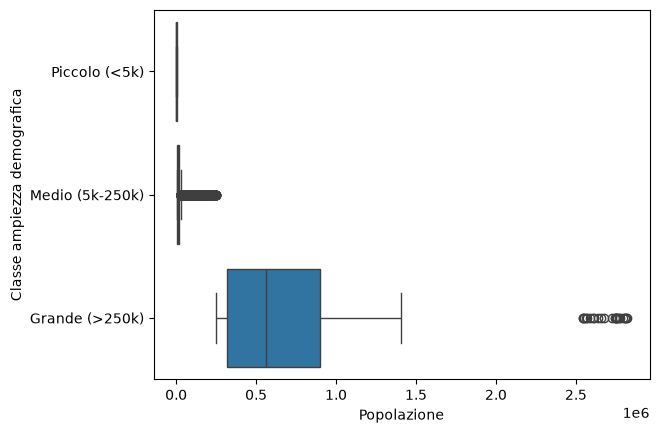

In [ ]:
sns.boxplot(x='Popolazione', y='Classe ampiezza demografica', data=df)
# piccoli comuni sono i più omogenei.
# Medi hanno valori estremi
# Grandi Comuni c'è forse sempre Roma valore estremo. ma non outliers per quella classe.

## Incidenti

<Axes: xlabel='Incidenti', ylabel='Classe ampiezza demografica'>

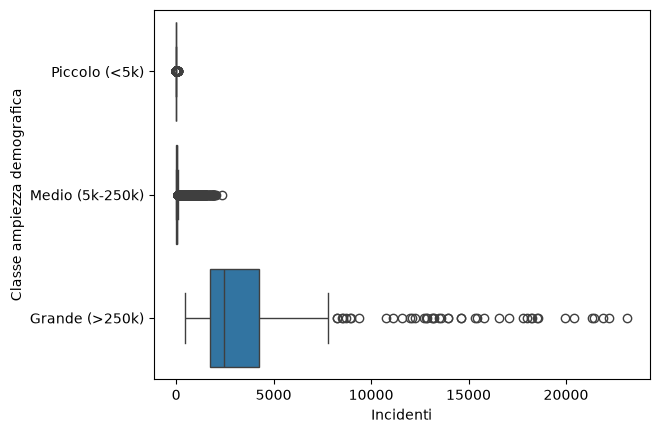

In [ ]:
sns.boxplot(x='Incidenti', y='Classe ampiezza demografica', data=df)
#compatti i comuni piccoli, valori estremi in Medi e Grandi.

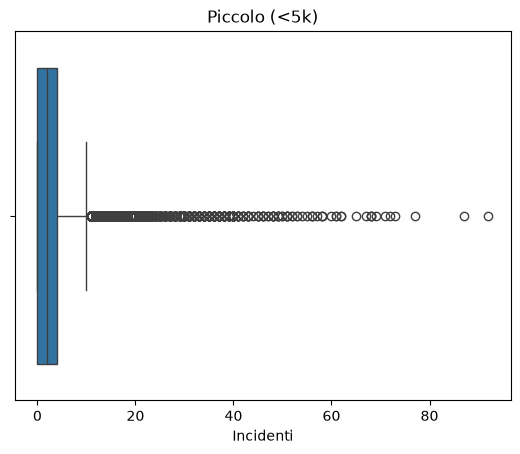

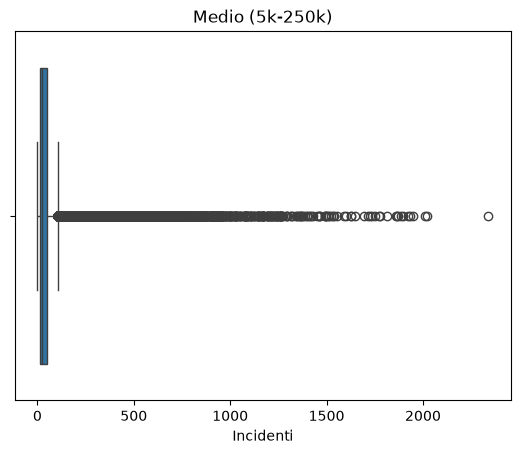

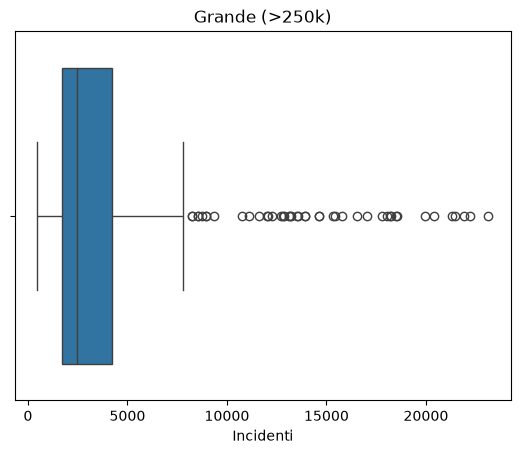

In [ ]:
list = df['Classe ampiezza demografica'].unique().tolist()
for i in list:
    sns.boxplot(x='Incidenti', data = df[df['Classe ampiezza demografica'] == i]).set_title( i )
    plt.show()


## Incidenti x 1000ab

In [72]:
df_incidentix1000ab = df.groupby('Codice Comune', as_index=False)['Incidentix1000abitanti'].mean()
df_incidentix1000ab

,Codice Comune,Incidentix1000abitanti
0,1001,1.47464
1,1002,2.90296
2,1003,0.60856
3,1004,2.62896
4,1005,1.717
...,...,...
8573,111103,1.277111
8574,111104,2.145889
8575,111105,1.945444
8576,111106,1.926667


<Axes: xlabel='Incidentix1000abitanti'>

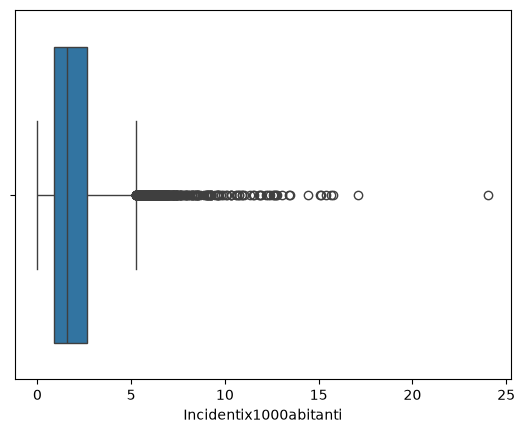

In [73]:
df_incidentix1000ab['Incidentix1000abitanti'].describe()
sns.boxplot(x='Incidentix1000abitanti', data=df_incidentix1000ab)


<Axes: xlabel='Incidentix1000abitanti', ylabel='Count'>

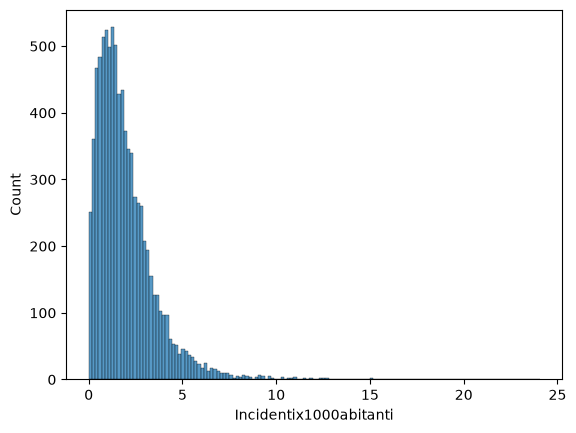

In [75]:
sns.histplot(x = 'Incidentix1000abitanti', data = df_incidentix1000ab)